# Fase 8-10: Preprocessing, feature engineering y feature selection

## 8. Preprocessing seguro

- Limpieza base (fases 2-3): solo días hábiles, forward-fill, features con cobertura suficiente -> `data/interim`.
- **Escalado (RobustScaler) ajustado SOLO con train** y aplicado con `transform` a val/test.
- No hay imputación con estado: el ffill ya usa solo pasado.

## 9. Feature engineering (serie temporal)

- **Lags del target:** 1, 2, 3, 5, 10, 21 (días hábiles).
- **Retornos logarítmicos** del target a esos lags.
- **Rolling:** retorno y media/desv. móvil a 5, 21, 63, 126 días.
- **Exógenas:** lag 1 de cada una + retorno log del lag (siempre positivas).
- **Calendario:** año, mes, día de semana, trimestre, día del año.
- **Indicadores de ausencia:** si la exógena faltaba en origen, marca 1/0.

Todas las ventanas miran **solo hacia atrás** (sin futuro) -> sin leakage.

## 10. Feature selection

- **Reglas:** se eliminan features excluidas por cobertura (config) y el target/date.
- **Filtro:** correlación de Pearson; si dos features correlacionan >0.98, se elimina una.
- **Embedded (fase 15):** importancia de XGBoost para el informe.

---

> **Aviso de auditoria:** las cifras y salidas mostradas en este notebook corresponden a una ejecucion anterior a las correcciones metodologicas. Es necesario reejecutar el pipeline completo antes de usar o comunicar sus resultados.


Configuración del notebook (raíz del proyecto).

In [1]:
import sys
from pathlib import Path

def _find_root() -> Path:
    p = Path.cwd().resolve()
    for candidate in (p, *p.parents):
        if (candidate / "configs" / "config.yaml").is_file():
            return candidate
    raise FileNotFoundError(
        "No se encontro configs/config.yaml desde el directorio de trabajo. "
        "Abra Jupyter dentro del repositorio."
    )

ROOT = _find_root()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
from src.utils import set_publication_style, set_seed
set_seed(42)
set_publication_style()

Carga de features y verificación de integridad.

Comprobamos que no hay NaNs en train (el warm-up ya los eliminó) y que el
numero de features se documenta a partir de la configuracion y ejecucion actual.

In [2]:
import numpy as np
import pandas as pd

from src.config import get_config
from src.data.split import drop_warmup, temporal_split, purge_label_overlap
from src.features.build_features import get_feature_columns
from src.utils import path_from_root

cfg = get_config()
feats = pd.read_parquet(path_from_root("data/processed/features.parquet"))
feats = drop_warmup(feats, warmup=260)
parts = temporal_split(feats, cfg)
parts = purge_label_overlap(parts, cfg=cfg)

feat_cols = get_feature_columns(feats, cfg["target"]["horizons"])
print("Features totales:", len(feat_cols))

X_train = parts["train"][feat_cols].to_numpy(dtype=np.float64)
print("NaN en train (features):", np.isnan(X_train).sum())
assert not np.isnan(X_train).any(), "Hay NaNs en train"

Features totales: 128
NaN en train (features): 0


Preprocesador ajustado SOLO con train.

RobustScaler (percentiles 5-95) reduce el impacto de outliers. El `fit` se
hace únicamente con train; val/test usan `transform` (nunca refit).

In [3]:
from src.models.pipeline import fit_preprocessor

pp = fit_preprocessor(X_train)
print("Preprocesador ajustado en train:", type(pp[0]).__name__)

Preprocesador ajustado en train: RobustScaler


Selección por correlación (redundancia > 0.98).

Buscamos pares de features con |rho| > 0.98 (colinealidad extrema). De cada
par eliminamos el miembro con menor varianza, priorizando conservar los
niveles (sin sufijo _lag1) frente a sus lags/retornos.

In [4]:
# Excluir columnas constantes (varianza 0): no aportan información
# y distorsionan la selección (p.ej. policy_uncertainty_missing)
const_cols = [c for c in feat_cols if parts["train"][c].var() < 1e-10]
if const_cols:
    print(f"Columnas constantes excluidas: {const_cols}")
feat_cols = [c for c in feat_cols if c not in const_cols]

corr = parts["train"][feat_cols].corr().abs()
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))
high = [(upper.columns[i], upper.columns[j], round(upper.iloc[i, j], 3))
        for i in range(len(upper)) for j in range(i + 1, len(upper))
        if upper.iloc[i, j] > 0.98]
print(f"Pares con correlación > 0.98: {len(high)}")
for a, b, v in high[:15]:
    print(f"  {a} ~ {b}: {v}")

def _priority(c: str) -> int:
    """Prioridad: 0 = derivada (lag/retorno), 1 = nivel base."""
    return 0 if c.endswith(("_lag1", "_ret_lag1")) else 1

drop_set = set()
for a, b, _ in high:
    if _priority(a) != _priority(b):
        drop_set.add(a if _priority(a) < _priority(b) else b)
    else:
        va, vb = parts["train"][a].var(), parts["train"][b].var()
        drop_set.add(a if va <= vb else b)

sel_cols = [c for c in feat_cols if c not in drop_set]
print(f"\nFeatures tras filtro de redundancia: {len(feat_cols)} -> {len(sel_cols)}")
print("Eliminadas:", sorted(drop_set))

Columnas constantes excluidas: ['policy_uncertainty_missing']


Pares con correlación > 0.98: 119
  us10y_yield ~ us10y_yield_lag1: 0.999
  usdjpy_exchange ~ usdjpy_exchange_lag1: 0.999
  silver_futures ~ silver_spot: 1.0
  silver_futures ~ silver_futures_lag1: 0.999
  silver_futures ~ silver_spot_lag1: 0.999
  eurusd_exchange ~ eurusd_exchange_lag1: 0.999
  gold_futures ~ gold_spot_lag1: 1.0
  gold_futures ~ gold_spot_lag2: 0.999
  gold_futures ~ gold_spot_lag3: 0.999
  gold_futures ~ gold_spot_lag5: 0.998
  gold_futures ~ gold_spot_lag10: 0.997
  gold_futures ~ gold_spot_lag21: 0.994
  gold_futures ~ gold_rollmean_5: 1.0
  gold_futures ~ gold_rollmean_21: 0.998
  gold_futures ~ gold_rollmean_63: 0.995

Features tras filtro de redundancia: 127 -> 83
Eliminadas: ['brent_futures', 'brent_futures_lag1', 'brent_spot_lag1', 'commodities_bloomberg_lag1', 'commodities_crb_lag1', 'copper_futures_lag1', 'credit_spread_lag1', 'dxy_future', 'dxy_future_lag1', 'dxy_index_lag1', 'eurusd_exchange_lag1', 'eurusd_exchange_missing', 'gold_futures', 'gold_futures_l

Guardado de la lista de features seleccionadas.

Esta lista (83 features) es un artefacto clave: la API y el CLI la usan
para validar entradas y construir el vector en el orden exacto de
entrenamiento.

In [5]:
import json

from src.utils import path_from_root

out_path = path_from_root("models", "feature_list.json")
out_path.parent.mkdir(parents=True, exist_ok=True)
with open(out_path, "w") as f:
    json.dump(sel_cols, f, indent=2)
print(f"Lista de features guardada en {out_path} ({len(sel_cols)})")

Lista de features guardada en C:\Users\sgml1\Desktop\gold-price-prediction\models\feature_list.json (83)


Visualización de la reducción de features.

Gráfico de barras con el número de features antes/después del filtro de
redundancia, y un heatmap de correlación de las 83 features finales para
verificar que no quedan pares extremadamente colineales.

[fig] C:\Users\sgml1\Desktop\gold-price-prediction\reports\figures\feature_selection.png


WindowsPath('C:/Users/sgml1/Desktop/gold-price-prediction/reports/figures/feature_selection.png')

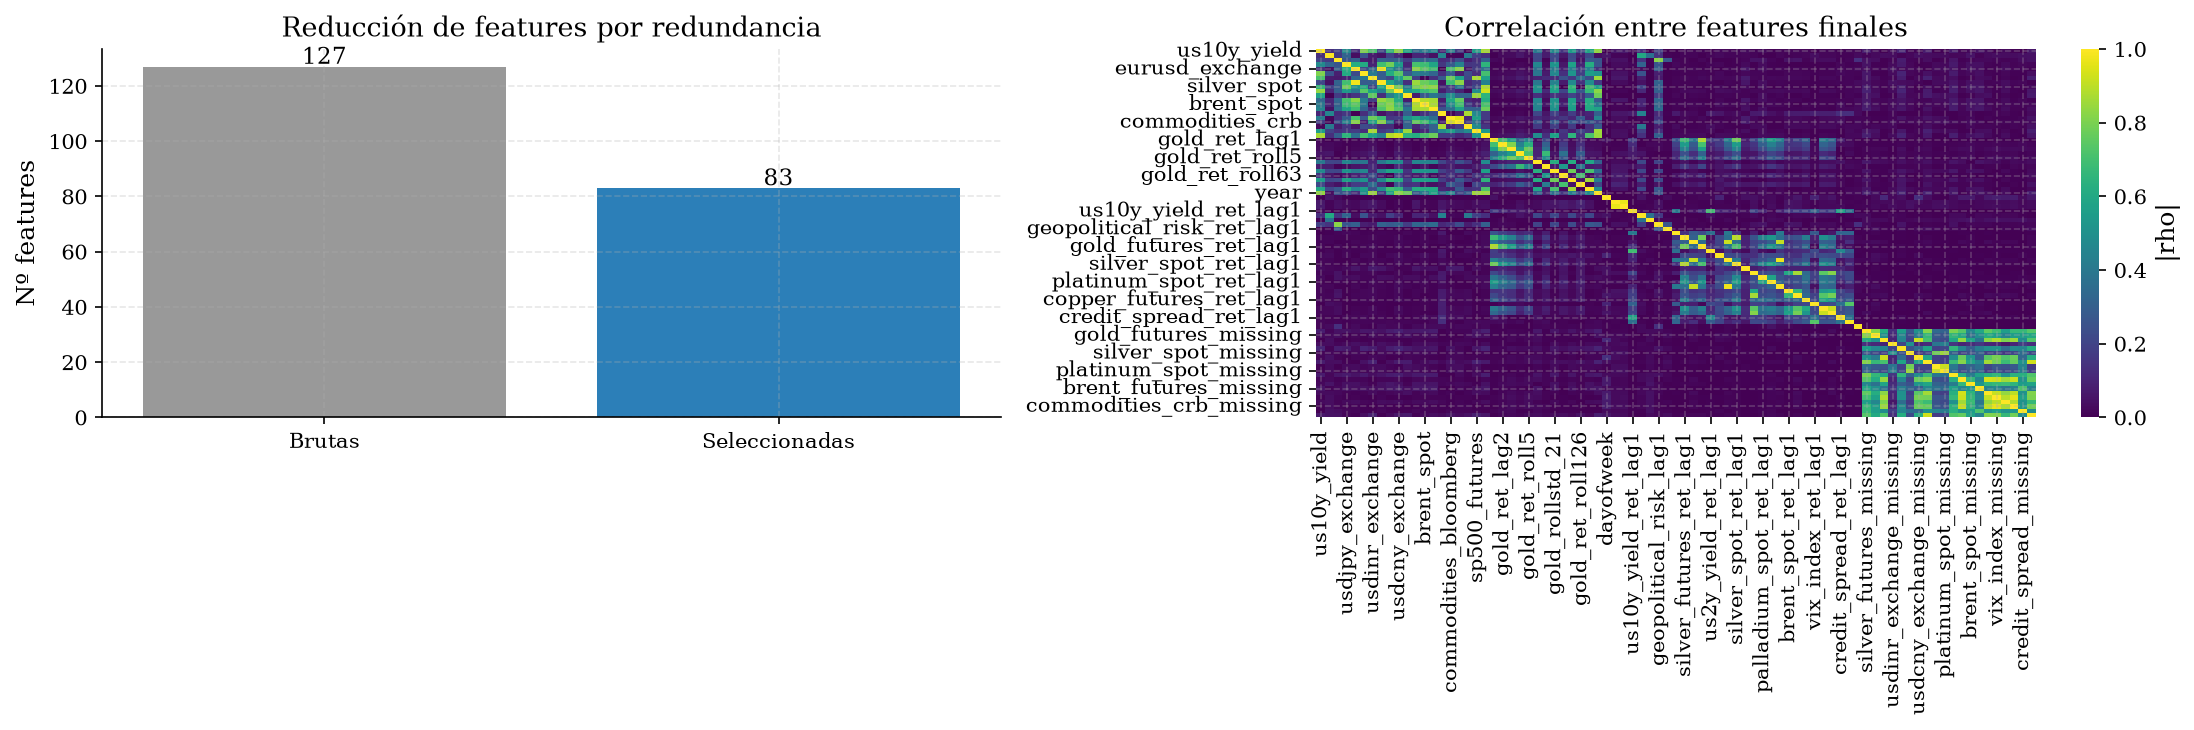

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].bar(["Brutas", "Seleccionadas"], [len(feat_cols), len(sel_cols)],
            color=["#999", "#2c7fb8"])
axes[0].set_title("Reducción de features por redundancia")
axes[0].set_ylabel("Nº features")
for i, v in enumerate([len(feat_cols), len(sel_cols)]):
    axes[0].text(i, v + 1, str(v), ha="center")

corr_final = parts["train"][sel_cols].corr().abs()
sns.heatmap(corr_final, cmap="viridis", vmin=0, vmax=1, ax=axes[1],
            cbar_kws={"label": "|rho|"})
axes[1].set_title("Correlación entre features finales")
plt.tight_layout()

from src.utils import save_fig
save_fig(fig, "feature_selection.png")

## Análisis complementario: PCA exploratorio

El Análisis de Componentes Principales (PCA) sobre las features escaladas
(solo train) permite evaluar la estructura de varianza del conjunto:

- **Scree plot**: número de componentes necesarios para explicar el 90-95%
  de la varianza.
- **Interpretación**: en datos financieros con lags correlacionados, pocos
  componentes concentran la varianza (redundancia estructural).
- **Uso**: exclusivamente exploratorio (no se usa PCA como transformación
  del modelo final, para preservar la interpretabilidad).


Componentes para 90% varianza: 23
Componentes para 95% varianza: 33
Varianza explicada PC1: 31.2%


[fig] C:\Users\sgml1\Desktop\gold-price-prediction\reports\figures\eda_pca_scree.png


WindowsPath('C:/Users/sgml1/Desktop/gold-price-prediction/reports/figures/eda_pca_scree.png')

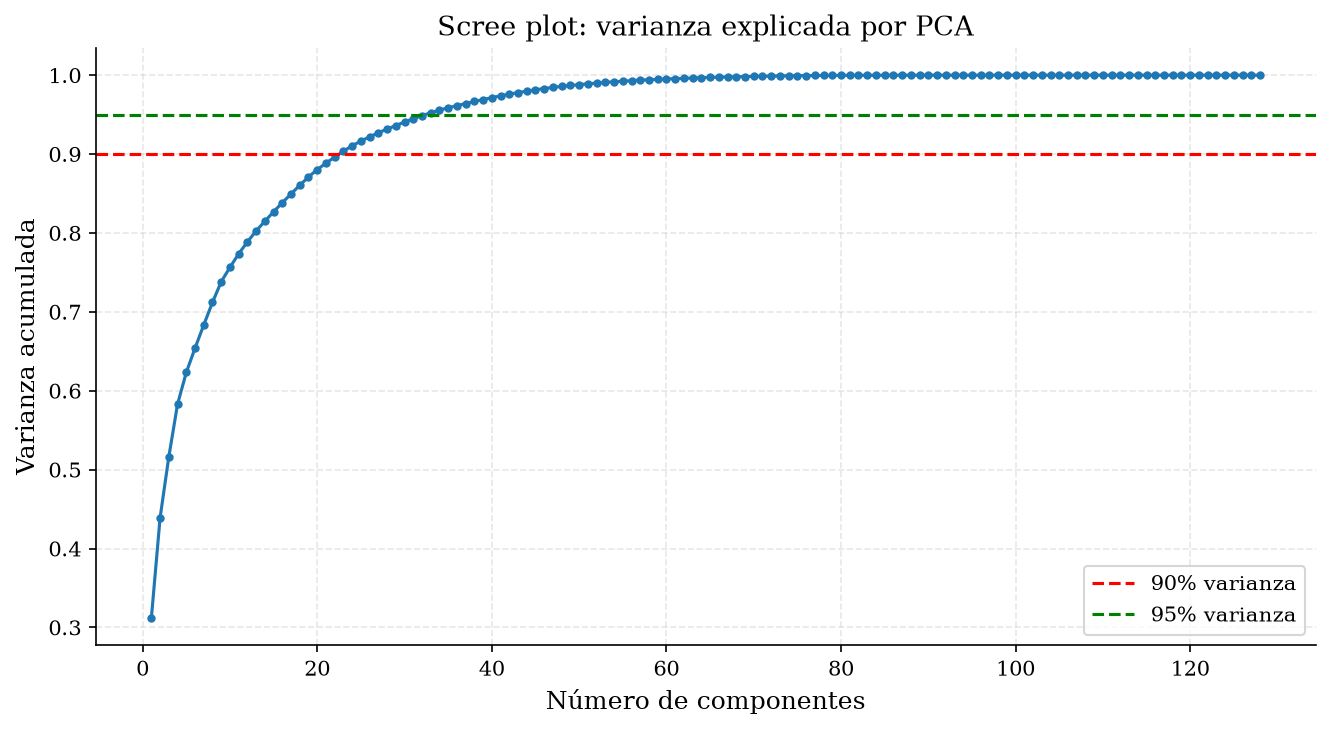

In [7]:
from sklearn.decomposition import PCA

# PCA sobre train escalado (solo exploratorio)
X_train_scaled = pp.transform(X_train)
pca = PCA()
pca.fit(X_train_scaled)
var_acum = np.cumsum(pca.explained_variance_ratio_)
n_90 = int(np.argmax(var_acum >= 0.90) + 1)
n_95 = int(np.argmax(var_acum >= 0.95) + 1)
print(f"Componentes para 90% varianza: {n_90}")
print(f"Componentes para 95% varianza: {n_95}")
print(f"Varianza explicada PC1: {pca.explained_variance_ratio_[0]:.1%}")

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(range(1, len(var_acum)+1), var_acum, 'o-', markersize=3)
ax.axhline(0.90, color='red', ls='--', label='90% varianza')
ax.axhline(0.95, color='green', ls='--', label='95% varianza')
ax.set_xlabel('Número de componentes')
ax.set_ylabel('Varianza acumulada')
ax.set_title('Scree plot: varianza explicada por PCA')
ax.legend()
fig.tight_layout()
save_fig(fig, "eda_pca_scree.png")


## Análisis complementario: Mutual Information y F-test

La selección por correlación (Pearson) captura solo relaciones lineales.
Complementamos con:

- **F-test** (ANOVA): relevancia lineal de cada feature con el target.
- **Mutual Information (MI)**: dependencia general, incluyendo relaciones
  no lineales y no monótonas.

Ambos se calculan SOLO con train (sin tocar test). Los resultados se
comparan con la importancia del modelo para validar coherencia.


In [8]:
h = cfg["target"]["primary_horizon"]

from sklearn.feature_selection import f_regression, mutual_info_regression

# Recalcular X_train con feat_cols actualizado (tras excluir constantes)
X_train = parts["train"][feat_cols].to_numpy(dtype=np.float64)

# F-test y MI (solo train)
y_train_1 = parts["train"][f"target_{h}"].to_numpy(np.float64)
f_stat, f_pval = f_regression(X_train, y_train_1)
mi_scores = mutual_info_regression(X_train, y_train_1, random_state=42)

mi_df = pd.DataFrame({"feature": feat_cols, "f_stat": f_stat, "f_pval": f_pval,
                      "mi": mi_scores}).sort_values("mi", ascending=False)
print("Top 10 por Mutual Information:")
print(mi_df.head(10).round(4).to_string(index=False))
print(chr(10) + "Top 10 por F-statistic:")
print(mi_df.sort_values("f_stat", ascending=False).head(10).round(2).to_string(index=False))

# Coherencia con features seleccionadas
sel_set = set(sel_cols)
print(chr(10) + "Features seleccionadas en top-20 MI: "
      f"{mi_df.head(20)['feature'].isin(sel_set).sum()}/20")
print("Features seleccionadas en top-20 F: "
      f"{mi_df.sort_values('f_stat', ascending=False).head(20)['feature'].isin(sel_set).sum()}/20")

Top 10 por Mutual Information:
          feature       f_stat  f_pval     mi
     gold_futures 6872194.3612     0.0 3.5368
   gold_spot_lag1 3994214.4149     0.0 3.2749
gold_futures_lag1 3715762.2130     0.0 3.2395
  gold_rollmean_5 3662947.5748     0.0 3.2132
   gold_spot_lag2 2673315.7666     0.0 3.0761
   gold_spot_lag3 2014416.5338     0.0 2.9442
 gold_rollmean_21 1098424.8523     0.0 2.8662
 gold_rollmean_63  440656.3250     0.0 2.8085
   gold_spot_lag5 1341059.6532     0.0 2.8074
gold_rollmean_126  233932.6149     0.0 2.7918

Top 10 por F-statistic:
          feature     f_stat  f_pval   mi
     gold_futures 6872194.36     0.0 3.54
   gold_spot_lag1 3994214.41     0.0 3.27
gold_futures_lag1 3715762.21     0.0 3.24
  gold_rollmean_5 3662947.57     0.0 3.21
   gold_spot_lag2 2673315.77     0.0 3.08
   gold_spot_lag3 2014416.53     0.0 2.94
   gold_spot_lag5 1341059.65     0.0 2.81
 gold_rollmean_21 1098424.85     0.0 2.87
  gold_spot_lag10  739179.33     0.0 2.54
 gold_rollmean_63 

## Análisis complementario: clustering por correlación

Método más riguroso que el filtro simple: agrupa features altamente
correlacionadas en clusters y selecciona un representante por cluster
(priorizando las de mayor relevancia). Complementa al filtro |rho|>0.98
ya aplicado, usando un umbral más estricto (0.95) sobre las features
ya seleccionadas.


In [9]:
from scipy.cluster.hierarchy import linkage, fcluster
from scipy.spatial.distance import squareform
import numpy as np

# Clustering jerarquico sobre 1 - |correlacion| (solo train)
corr_sel = parts["train"][sel_cols].corr().abs().fillna(0)
# Forzar simetria exacta y diagonal a 0 (matriz de distancia)
dist_mat = 1 - corr_sel.values
dist_mat = (dist_mat + dist_mat.T) / 2
np.fill_diagonal(dist_mat, 0)
dist = squareform(dist_mat)
Z = linkage(dist, method="average")
clusters = fcluster(Z, t=0.05, criterion="distance")  # umbral 0.95 correlacion

# Representante por cluster: el de mayor MI
cl_df = pd.DataFrame({"feature": sel_cols, "cluster": clusters})
cl_df = cl_df.merge(mi_df[["feature", "mi"]], on="feature", how="left")
reps = cl_df.sort_values("mi", ascending=False).groupby("cluster").first()
print(f"Clusters formados: {clusters.max()} | features: {len(sel_cols)}")
print(f"Representantes: {len(reps)}")
print(chr(10) + "Clusters con mas de 1 miembro (redundancia detectada):")
multi = cl_df.groupby("cluster").filter(lambda g: len(g) > 1)
for cl, g in multi.groupby("cluster"):
    print(f"  Cluster {cl}: {list(g['feature'])}")

Clusters formados: 78 | features: 83
Representantes: 78

Clusters con mas de 1 miembro (redundancia detectada):
  Cluster 10: ['vix_index_missing', 'commodities_crb_missing']
  Cluster 45: ['dxy_index_ret_lag1', 'dxy_future_ret_lag1']
  Cluster 50: ['quarter', 'dayofyear']
  Cluster 68: ['eurusd_exchange', 'dxy_index']
  Cluster 69: ['commodities_bloomberg', 'commodities_crb']
